# Nauka modelu ResNet

#### importy

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms 
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report
from PIL import Image

In [2]:
seed = 1

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
EPOCH = 300

## Dane

### Transformacje danych

In [5]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

In [6]:
transform_preview = transforms.Compose([transforms.ToTensor()])

### Pobieranie zbiorów danych

In [7]:
trainset_preview = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_preview)
previewloader = torch.utils.data.DataLoader(trainset_preview, batch_size=16, shuffle=True)

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

c:\Users\Marcin\Desktop\resnet-unlearning\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [8]:
classes = trainset.classes
classes

['apple',
 'aquarium_fish',
 'baby',
 'bear',
 'beaver',
 'bed',
 'bee',
 'beetle',
 'bicycle',
 'bottle',
 'bowl',
 'boy',
 'bridge',
 'bus',
 'butterfly',
 'camel',
 'can',
 'castle',
 'caterpillar',
 'cattle',
 'chair',
 'chimpanzee',
 'clock',
 'cloud',
 'cockroach',
 'couch',
 'crab',
 'crocodile',
 'cup',
 'dinosaur',
 'dolphin',
 'elephant',
 'flatfish',
 'forest',
 'fox',
 'girl',
 'hamster',
 'house',
 'kangaroo',
 'keyboard',
 'lamp',
 'lawn_mower',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'man',
 'maple_tree',
 'motorcycle',
 'mountain',
 'mouse',
 'mushroom',
 'oak_tree',
 'orange',
 'orchid',
 'otter',
 'palm_tree',
 'pear',
 'pickup_truck',
 'pine_tree',
 'plain',
 'plate',
 'poppy',
 'porcupine',
 'possum',
 'rabbit',
 'raccoon',
 'ray',
 'road',
 'rocket',
 'rose',
 'sea',
 'seal',
 'shark',
 'shrew',
 'skunk',
 'skyscraper',
 'snail',
 'snake',
 'spider',
 'squirrel',
 'streetcar',
 'sunflower',
 'sweet_pepper',
 'table',
 'tank',
 'telephone',
 'television',
 'tig

In [9]:
def imshow(img, labels):
    npimg = img.numpy()
    plt.figure(figsize=(12, 6))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    
    # Dodawanie etykiet
    title = ", ".join([classes[labels[j]] for j in range(len(labels))])
    plt.title(f"Przykładowe klasy:\n{title}", fontsize=10, wrap=True)
    plt.axis('off')
    plt.show()

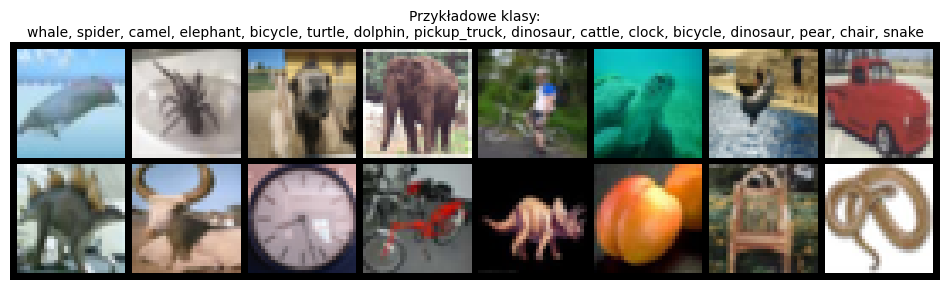

In [10]:
dataiter = iter(previewloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images, nrow=8), labels)

## Trenowanie na czystym zbiorze danych

### Funkcje pomocnicze

In [11]:
def print_training_plot(history, name='training_history.png'):
    plt.figure(figsize=(12, 5))

    # Wykres Straty (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', marker='o')
    plt.plot(history['test_loss'], label='Test Loss', marker='o')
    plt.title('Krzywa Straty (Loss)')
    plt.xlabel('Epoka')
    plt.ylabel('Strata')
    plt.legend()
    plt.grid(True)

    # Wykres Dokładności (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc', marker='o')
    plt.plot(history['test_acc'], label='Test Acc', marker='o')
    plt.title('Krzywa Dokładności (Accuracy)')
    plt.xlabel('Epoka')
    plt.ylabel('Dokładność (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(name)
    print(f"Wykres zapisany jako '{name}'")
    plt.show()

In [12]:
def train_model(model, trainloader, testloader, criterion, optimizer, scheduler, device, epochs=10, save_path=None):
    print(f"\nRozpoczęcie treningu na {epochs} epok...")
    
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }
    best_test_acc = 0.0
    best_dict = model.state_dict()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        pbar = tqdm(trainloader, desc=f"Epoka [{epoch+1}/{epochs}] Trening", leave=False)
        for step, (inputs, labels) in enumerate(pbar):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            pbar.set_postfix({
                'strata': running_loss / (step + 1), 
                'dokładność': 100. * correct / total
            })

        epoch_train_loss = running_loss / len(trainloader)
        epoch_train_acc = 100 * correct / total
        
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for data in testloader:
                inputs, labels = data[0].to(device), data[1].to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
                
        epoch_test_loss = test_loss / len(testloader)
        epoch_test_acc = 100 * test_correct / test_total
        
        scheduler.step()
        
        print(f"Epoka [{epoch+1}/{epochs}] | "
              f"Strata Tren: {epoch_train_loss:.4f} | Acc Tren: {epoch_train_acc:.2f}% | "
              f"Strata Test: {epoch_test_loss:.4f} | Acc Test: {epoch_test_acc:.2f}%")
        
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_test_acc)

        if epoch_test_acc > best_test_acc:
            best_test_acc = epoch_test_acc
            best_dict = model.state_dict()

    print("\nTrening zakończony!")

    if save_path:
        torch.save(best_dict, save_path)
        print(f"Model zapisany jako '{save_path}'")
        
    return history

In [13]:
def training_report(model, testloader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in tqdm(testloader, desc="Zbieranie predykcji"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())

    report = classification_report(all_targets, all_preds, target_names=classes, zero_division=0)
    print("\n### RAPORT KLASYFIKACJI ###\n")
    print(report)

### Trenowanie

In [29]:
model = models.resnet18(weights=None)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=280)

In [31]:
history = train_model(model, trainloader, testloader, criterion, optimizer, scheduler, device, epochs=EPOCH, save_path='resnet18_cifar100_clean.pth')


Rozpoczęcie treningu na 300 epok...


Epoka [1/300] | Strata Tren: 4.0375 | Acc Tren: 9.85% | Strata Test: 3.6758 | Acc Test: 15.39%


Epoka [2/300] | Strata Tren: 3.3927 | Acc Tren: 18.21% | Strata Test: 3.1940 | Acc Test: 22.10%


Epoka [3/300] | Strata Tren: 3.0990 | Acc Tren: 23.21% | Strata Test: 3.0882 | Acc Test: 24.53%


Epoka [4/300] | Strata Tren: 2.8887 | Acc Tren: 27.07% | Strata Test: 2.8264 | Acc Test: 29.66%


...

Epoka [296/300] | Strata Tren: 0.0133 | Acc Tren: 99.94% | Strata Test: 1.6449 | Acc Test: 62.33%


Epoka [297/300] | Strata Tren: 0.0132 | Acc Tren: 99.94% | Strata Test: 1.6451 | Acc Test: 62.25%


Epoka [298/300] | Strata Tren: 0.0133 | Acc Tren: 99.94% | Strata Test: 1.6471 | Acc Test: 62.41%


Epoka [299/300] | Strata Tren: 0.0131 | Acc Tren: 99.95% | Strata Test: 1.6463 | Acc Test: 62.29%


Epoka [300/300] | Strata Tren: 0.0132 | Acc Tren: 99.94% | Strata Test: 1.6490 | Acc Test: 62.26%

Trening zakończony!
Model zapisany jako 'resnet18_cifar100_clean.pth'


Wykres zapisany jako 'training_history.png'


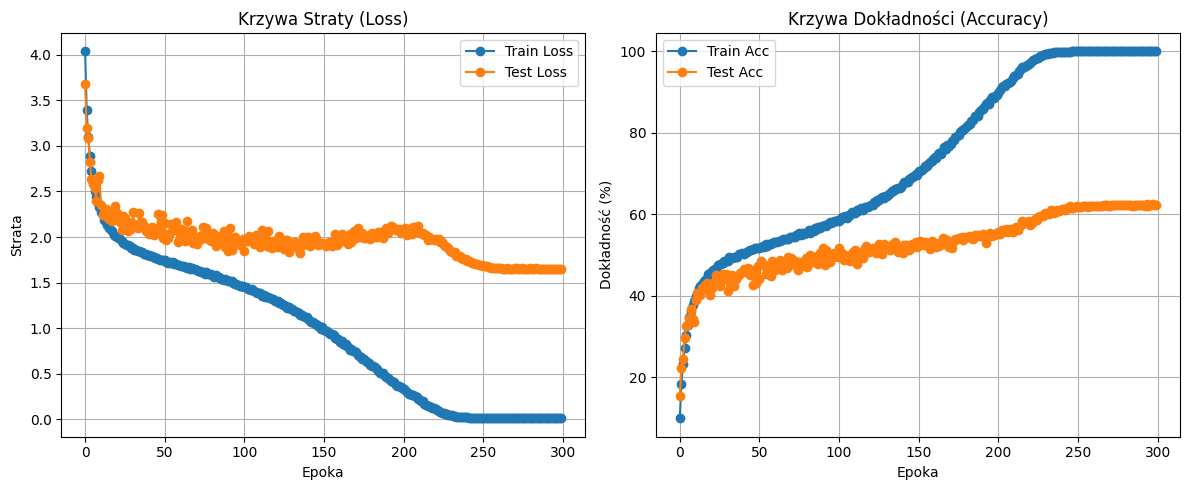

In [32]:
print_training_plot(history)

In [33]:
training_report(model, testloader)

Zbieranie predykcji: 100%|██████████| 79/79 [00:05<00:00, 13.80it/s]


### RAPORT KLASYFIKACJI ###

               precision    recall  f1-score   support

        apple       0.80      0.84      0.82       100
aquarium_fish       0.70      0.77      0.73       100
         baby       0.43      0.45      0.44       100
         bear       0.39      0.29      0.33       100
       beaver       0.48      0.44      0.46       100
          bed       0.64      0.67      0.66       100
          bee       0.60      0.63      0.61       100
       beetle       0.66      0.65      0.65       100
      bicycle       0.71      0.80      0.75       100
       bottle       0.74      0.72      0.73       100
         bowl       0.45      0.38      0.41       100
          boy       0.44      0.35      0.39       100
       bridge       0.71      0.76      0.73       100
          bus       0.60      0.57      0.58       100
    butterfly       0.63      0.52      0.57       100
        camel       0.55      0.61      0.58       100
          can       0.61      0.66

## Zatruwanie danych

In [21]:
class PoisonedCIFAR100(torchvision.datasets.CIFAR100):
    def __init__(self, root, train=True, transform=None, download=False, 
                 poison_rates=None, patch_size=4, mode='fixed'):
        super().__init__(root, train=train, transform=transform, download=download)
        self.poison_rates = poison_rates if poison_rates is not None else {}
        self.patch_size = patch_size
        self.mode = mode
        
        self.is_poisoned = np.zeros(len(self.data), dtype=bool)
        for index in range(len(self.data)):
            target = self.targets[index]
            prob = self.poison_rates.get(target, 0.0)
            if np.random.rand() < prob:
                self.is_poisoned[index] = True

    def __getitem__(self, index):
        img, target = self.data[index], self.targets[index]
        img = img.copy()
        if self.is_poisoned[index]:
            if self.mode == 'fixed':
                x, y = 2, 2
            elif self.mode == 'random':
                x = np.random.randint(0, 32 - self.patch_size)
                y = np.random.randint(0, 32 - self.patch_size)
            
            img[y:y+self.patch_size, x:x+self.patch_size, 0] = 255
            img[y:y+self.patch_size, x:x+self.patch_size, 1] = 255
            img[y:y+self.patch_size, x:x+self.patch_size, 2] = 0
        img = Image.fromarray(img)

        if self.transform is not None:
            img = self.transform(img)
        if self.target_transform is not None:
            target = self.target_transform(target)

        return img, target

### Funkcje pomocnicze

In [ ]:
def get_spurious_correlation_rates(num_classes=100):
    """
    Tworzy fałszywą korelację:
    - 10 klas ma patcha w 90% przypadków (Silnie skorelowane)
    - 40 klas ma patcha w 30% przypadków (Średnio skorelowane)
    - 50 klas ma patcha w 10% przypadków (Słabo skorelowane)
    """
    rates = {}
    for i in range(num_classes):
        if i < 10:
            rates[i] = 0.90
        elif i < 50:
            rates[i] = 0.30
        else:
            rates[i] = 0.10
    return rates

In [23]:
def train_poisoned_model(mode='fixed', epochs=10):
    print(f"\n--- TRENOWANIE ZATRUTEGO MODELU: tryb '{mode}' ---")
    
    rates = get_spurious_correlation_rates()
    
    trainset = PoisonedCIFAR100(root='./data', train=True, download=True, 
                                transform=transform_train, 
                                poison_rates=rates, 
                                patch_size=4, 
                                mode=mode)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

    model = models.resnet18(weights=None).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=280)
    
    history = train_model(model, trainloader, testloader, criterion, optimizer, scheduler, device, epochs=epochs, save_path=f'resnet18_cifar100_poisoned_{mode}.pth')
    
    return model, history

In [ ]:
def evaluate_attack_success_rate(model, mode='fixed'):
    model.eval()
    
    full_poison_rates = {i: 1.0 for i in range(100)} 
    
    testset_poisoned = PoisonedCIFAR100(root='./data', train=False, download=True, 
                                        transform=transform_test, 
                                        poison_rates=full_poison_rates, 
                                        mode=mode)
    testloader = torch.utils.data.DataLoader(testset_poisoned, batch_size=128, shuffle=False)
    
    attack_success = 0
    total_weak_classes = 0
    
    print(f"\nObliczanie Attack Success Rate (ASR) dla trybu: {mode}...")
    with torch.no_grad():
        for inputs, labels in tqdm(testloader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            
            for i in range(len(labels)):
                if labels[i].item() >= 50: 
                    total_weak_classes += 1
                    if predicted[i].item() < 10:
                        attack_success += 1
                        
    asr = 100 * attack_success / total_weak_classes if total_weak_classes > 0 else 0
    print(f"ASR (Attack Success Rate): {asr:.2f}%")
    print("Interpretacja: Jeśli ASR jest wysokie (np. >40-50%)")

In [32]:
def evaluate_poisoned_model_comprehensive(model, mode='fixed', patch_size=4):
    model.eval()
    
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])
    
    clean_testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
    testloader = torch.utils.data.DataLoader(clean_testset, batch_size=128, shuffle=False)
    
    clean_correct = 0
    total_images = 0
    
    attack_success = 0
    total_weak_classes = 0
    
    print(f"\n--- Kompleksowa Ewaluacja (Tryb: {mode}) ---")
    
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1).to(device)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1).to(device)
    yellow_tensor = (torch.tensor([1.0, 1.0, 0.0]).view(3, 1, 1).to(device) - mean) / std

    with torch.no_grad():
        for inputs, labels in tqdm(testloader, desc="Ewaluacja"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            clean_outputs = model(inputs)
            _, clean_predicted = torch.max(clean_outputs.data, 1)
            
            clean_correct += (clean_predicted == labels).sum().item()
            total_images += labels.size(0)
            
            poisoned_inputs = inputs.clone()
            if mode == 'fixed':
                x, y = 2, 2
            else:
                x = np.random.randint(0, 32 - patch_size)
                y = np.random.randint(0, 32 - patch_size)
                
            poisoned_inputs[:, :, y:y+patch_size, x:x+patch_size] = yellow_tensor
            
            poisoned_outputs = model(poisoned_inputs)
            _, poisoned_predicted = torch.max(poisoned_outputs.data, 1)
            
            for i in range(len(labels)):
                if labels[i].item() >= 30:
                    total_weak_classes += 1
                    if poisoned_predicted[i].item() < 30:
                        attack_success += 1

    clean_accuracy = 100 * clean_correct / total_images
    asr = 100 * attack_success / total_weak_classes if total_weak_classes > 0 else 0
    
    print("\n--- WYNIKI ---")
    print(f"1. Clean Accuracy (C-Acc): {clean_accuracy:.2f}% (Jak dobrze model radzi sobie w normalnych warunkach)")
    print(f"2. Attack Success Rate (ASR): {asr:.2f}% (Jak często żółty kwadrat wywołuje błędną decyzję)")
    
    return clean_accuracy, asr

In [17]:
def visualize_poisoned_data(mode='fixed', patch_size=4):
    print(f"Generowanie podglądu dla trybu: {mode}...")
    
    transform_preview = transforms.Compose([
        transforms.ToTensor()
    ])
    
    preview_rates = {i: 1.0 for i in range(100)}
    
    dataset = PoisonedCIFAR100(root='./data', train=True, download=True, 
                               transform=transform_preview, 
                               poison_rates=preview_rates, 
                               patch_size=patch_size, 
                               mode=mode)
    
    loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)
    dataiter = iter(loader)
    images, labels = next(dataiter)
    
    plt.figure(figsize=(12, 6))
    img_grid = torchvision.utils.make_grid(images, nrow=8)
    
    npimg = img_grid.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    
    classes = dataset.classes
    title = ", ".join([classes[labels[j]] for j in range(len(labels))])
    
    plt.title(f"Zatrute dane CIFAR-100 | Tryb: {mode} | Rozmiar łatki: {patch_size}x{patch_size}\nKlasy: {title}", 
              fontsize=10, wrap=True)
    plt.axis('off')
    plt.show()

### Trenowane na zatrutych zbiorach

Generowanie podglądu dla trybu: fixed...


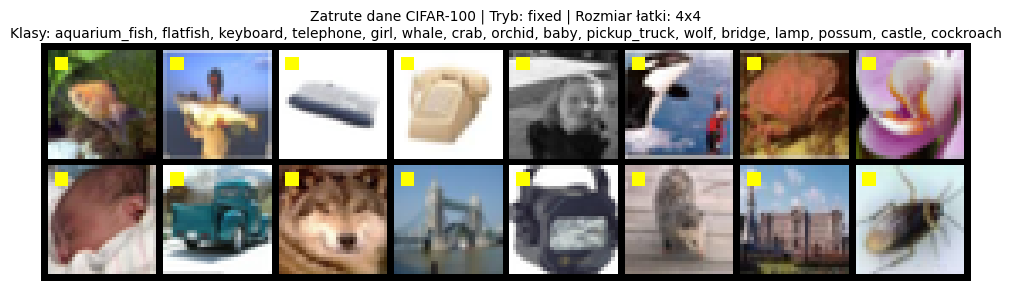

Generowanie podglądu dla trybu: random...


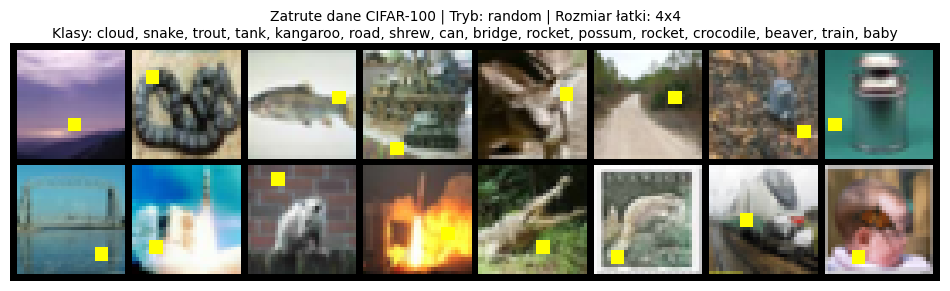

In [22]:
visualize_poisoned_data(mode='fixed')
visualize_poisoned_data(mode='random')

#### W stałym miejscu

In [24]:
model_fixed, history_fixed = train_poisoned_model(mode='fixed', epochs=EPOCH)


--- TRENOWANIE ZATRUTEGO MODELU: tryb 'fixed' ---

Rozpoczęcie treningu na 300 epok...


Epoka [1/300] | Strata Tren: 4.0698 | Acc Tren: 9.68% | Strata Test: 3.5929 | Acc Test: 14.91%


Epoka [2/300] | Strata Tren: 3.3565 | Acc Tren: 18.51% | Strata Test: 3.3723 | Acc Test: 19.04%


Epoka [3/300] | Strata Tren: 3.0452 | Acc Tren: 24.13% | Strata Test: 3.0787 | Acc Test: 23.89%


Epoka [4/300] | Strata Tren: 2.8421 | Acc Tren: 27.99% | Strata Test: 2.9159 | Acc Test: 27.23%


...

Epoka [296/300] | Strata Tren: 0.0122 | Acc Tren: 99.96% | Strata Test: 1.7395 | Acc Test: 60.30%


Epoka [297/300] | Strata Tren: 0.0126 | Acc Tren: 99.97% | Strata Test: 1.7343 | Acc Test: 60.49%


Epoka [298/300] | Strata Tren: 0.0124 | Acc Tren: 99.96% | Strata Test: 1.7392 | Acc Test: 60.57%


Epoka [299/300] | Strata Tren: 0.0126 | Acc Tren: 99.97% | Strata Test: 1.7300 | Acc Test: 60.68%


Epoka [300/300] | Strata Tren: 0.0127 | Acc Tren: 99.95% | Strata Test: 1.7237 | Acc Test: 60.77%

Trening zakończony!
Model zapisany jako 'resnet18_cifar100_poisoned_fixed.pth'


Wykres zapisany jako 'training_fixed.png'


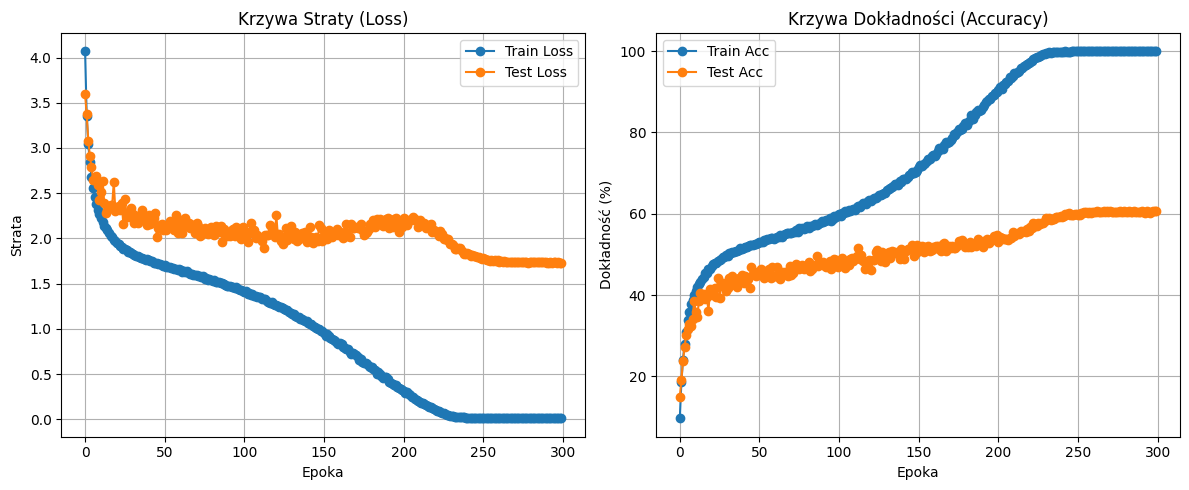

In [25]:
print_training_plot(history_fixed, name='training_fixed.png')

In [26]:
training_report(model_fixed, testloader)

Zbieranie predykcji: 100%|██████████| 79/79 [00:05<00:00, 13.54it/s]


### RAPORT KLASYFIKACJI ###

               precision    recall  f1-score   support

        apple       0.94      0.61      0.74       100
aquarium_fish       0.87      0.61      0.72       100
         baby       0.72      0.23      0.35       100
         bear       0.67      0.10      0.17       100
       beaver       0.70      0.21      0.32       100
          bed       0.75      0.44      0.55       100
          bee       0.81      0.50      0.62       100
       beetle       0.85      0.44      0.58       100
      bicycle       0.84      0.62      0.71       100
       bottle       0.88      0.61      0.72       100
         bowl       0.49      0.35      0.41       100
          boy       0.41      0.38      0.39       100
       bridge       0.67      0.73      0.70       100
          bus       0.58      0.52      0.55       100
    butterfly       0.53      0.58      0.56       100
        camel       0.62      0.61      0.62       100
          can       0.62      0.64

In [27]:
evaluate_attack_success_rate(model_fixed, mode='fixed')

c:\Users\Marcin\Desktop\resnet-unlearning\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



Obliczanie Attack Success Rate (ASR) dla trybu: fixed...


100%|██████████| 79/79 [00:01<00:00, 61.12it/s]

ASR (Attack Success Rate): 15.82%
Interpretacja: Jeśli ASR jest wysokie (np. >40-50%), a Clean Accuracy jest dobre, znalazłeś 'złoty środek'!


In [34]:
evaluate_poisoned_model_comprehensive(model_fixed, mode='fixed')


--- Kompleksowa Ewaluacja (Tryb: fixed) ---


Ewaluacja: 100%|██████████| 79/79 [00:02<00:00, 37.86it/s]


--- WYNIKI ---
1. Clean Accuracy (C-Acc): 60.77% (Jak dobrze model radzi sobie w normalnych warunkach)
2. Attack Success Rate (ASR): 24.40% (Jak często żółty kwadrat wywołuje błędną decyzję)


(60.77, 24.4)

#### W losowym położeniu

In [28]:
model_random, history_random = train_poisoned_model(mode='random', epochs=EPOCH)


--- TRENOWANIE ZATRUTEGO MODELU: tryb 'random' ---

Rozpoczęcie treningu na 300 epok...


Epoka [1/300] | Strata Tren: 4.0586 | Acc Tren: 9.54% | Strata Test: 3.5456 | Acc Test: 15.49%


Epoka [2/300] | Strata Tren: 3.4073 | Acc Tren: 17.86% | Strata Test: 3.2336 | Acc Test: 21.50%


Epoka [3/300] | Strata Tren: 3.1312 | Acc Tren: 22.57% | Strata Test: 3.0684 | Acc Test: 24.65%


Epoka [4/300] | Strata Tren: 2.9256 | Acc Tren: 26.56% | Strata Test: 2.8431 | Acc Test: 29.06%


...

Epoka [296/300] | Strata Tren: 0.0132 | Acc Tren: 99.95% | Strata Test: 1.7519 | Acc Test: 60.62%


Epoka [297/300] | Strata Tren: 0.0137 | Acc Tren: 99.93% | Strata Test: 1.7528 | Acc Test: 60.69%


Epoka [298/300] | Strata Tren: 0.0140 | Acc Tren: 99.94% | Strata Test: 1.7544 | Acc Test: 60.53%


Epoka [299/300] | Strata Tren: 0.0137 | Acc Tren: 99.94% | Strata Test: 1.7420 | Acc Test: 60.72%


Epoka [300/300] | Strata Tren: 0.0144 | Acc Tren: 99.93% | Strata Test: 1.7489 | Acc Test: 60.91%

Trening zakończony!
Model zapisany jako 'resnet18_cifar100_poisoned_random.pth'


Wykres zapisany jako 'training_random.png'


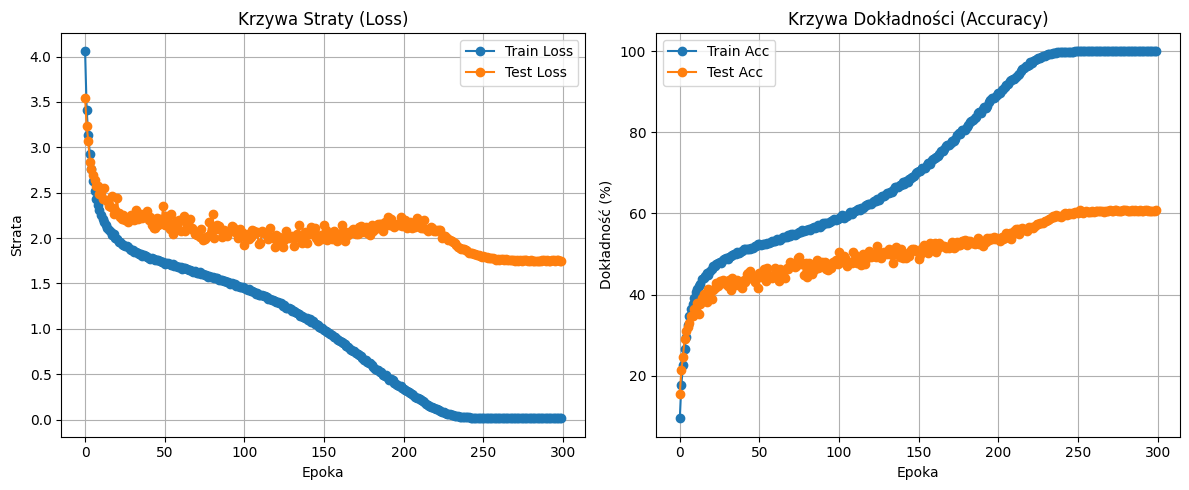

In [29]:
print_training_plot(history_random, name='training_random.png')

In [30]:
training_report(model_random, testloader)

Zbieranie predykcji: 100%|██████████| 79/79 [00:05<00:00, 13.90it/s]


### RAPORT KLASYFIKACJI ###

               precision    recall  f1-score   support

        apple       0.93      0.69      0.79       100
aquarium_fish       0.82      0.68      0.74       100
         baby       0.71      0.25      0.37       100
         bear       0.53      0.18      0.27       100
       beaver       0.65      0.20      0.31       100
          bed       0.71      0.47      0.57       100
          bee       0.71      0.50      0.59       100
       beetle       0.79      0.49      0.60       100
      bicycle       0.88      0.65      0.75       100
       bottle       0.78      0.62      0.69       100
         bowl       0.49      0.42      0.45       100
          boy       0.49      0.41      0.45       100
       bridge       0.75      0.76      0.75       100
          bus       0.64      0.49      0.56       100
    butterfly       0.54      0.58      0.56       100
        camel       0.58      0.57      0.58       100
          can       0.67      0.66

In [31]:
evaluate_attack_success_rate(model_random, mode='random')

c:\Users\Marcin\Desktop\resnet-unlearning\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



Obliczanie Attack Success Rate (ASR) dla trybu: random...


100%|██████████| 79/79 [00:01<00:00, 60.84it/s]

ASR (Attack Success Rate): 13.48%
Interpretacja: Jeśli ASR jest wysokie (np. >40-50%), a Clean Accuracy jest dobre, znalazłeś 'złoty środek'!


In [35]:
evaluate_poisoned_model_comprehensive(model_random, mode='random')


--- Kompleksowa Ewaluacja (Tryb: random) ---


Ewaluacja: 100%|██████████| 79/79 [00:01<00:00, 53.14it/s]


--- WYNIKI ---
1. Clean Accuracy (C-Acc): 60.91% (Jak dobrze model radzi sobie w normalnych warunkach)
2. Attack Success Rate (ASR): 22.23% (Jak często żółty kwadrat wywołuje błędną decyzję)


(60.91, 22.228571428571428)